In [2]:
# --- [TASK 2] SETUP AND PATH DEFINITION ---
from google.colab import drive
import os
import json

# Mount Google Drive
drive.mount('/content/drive')

# Path definitions
base_path = '/content/drive/MyDrive/COMP6001_Dataset'
sharp_path = os.path.join(base_path, 'val2017')
blurred_path = os.path.join(base_path, 'val2017_blurred_deterministic')
metadata_path = os.path.join(base_path, 'blur_metadata.json')

# Metadata extraction
if os.path.exists(metadata_path):
    with open(metadata_path, 'r') as f:
        data = json.load(f)
    # Extract the nested dictionary containing image data
    metadata = data.get('transformations', {})
    print(f"Status: Metadata extracted for {len(metadata)} images.")
else:
    print(f"Error: Metadata file not found at {metadata_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Status: Metadata extracted for 5000 images.


In [3]:
# --- [TASK 2] CORE RESTORATION FUNCTIONS ---
import cv2
import numpy as np
from skimage import restoration
from scipy.ndimage import shift

def create_precise_kernel(length, angle):
    """Generate normalized linear motion blur kernel."""
    size = int(round(length))
    if size % 2 == 0: size += 1
    kernel = np.zeros((size, size), dtype=np.float32)
    center = size // 2

    # Coordinate calculation
    angle_rad = np.deg2rad(angle)
    dx = (length / 2) * np.cos(angle_rad)
    dy = (length / 2) * np.sin(angle_rad)
    p1 = (int(center - dx), int(center - dy))
    p2 = (int(center + dx), int(center + dy))

    cv2.line(kernel, p1, p2, 1.0, 1)
    return kernel / np.sum(kernel)

def restore_image(img_blurred, length, angle, balance=0.01, alignment=(-1, 0)):
    """Apply Wiener filter and spatial phase correction."""
    psf = create_precise_kernel(length, angle)
    # Wiener Deconvolution
    restored = restoration.wiener(img_blurred, psf, balance=balance)
    restored = np.clip(restored, 0, 1)
    # Vertical shift compensation
    aligned = shift(restored, alignment)
    return aligned

Status: PSNR for 000000140076.jpg is 24.39 dB


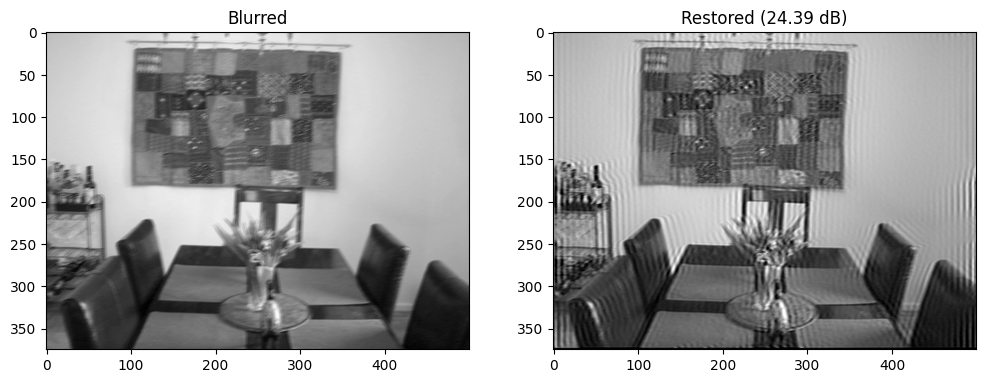

In [4]:
# --- [TASK 2] SINGLE IMAGE TEST ---
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr_metric

sample_file = '000000140076.jpg'
meta = metadata.get(sample_file)

if meta:
    # Path construction
    s_img_path = os.path.join(sharp_path, sample_file)
    b_img_path = os.path.join(blurred_path, sample_file)

    if os.path.exists(s_img_path) and os.path.exists(b_img_path):
        # Load and normalize
        img_s = cv2.imread(s_img_path, 0).astype(np.float32) / 255.0
        img_b = cv2.imread(b_img_path, 0).astype(np.float32) / 255.0

        # Restoration execution using metadata size and angle
        result = restore_image(img_b, meta['size'], meta['angle'], balance=0.01, alignment=(-1, 0))

        # Metric calculation
        psnr_final = psnr_metric(img_s, result, data_range=1.0)
        print(f"Status: PSNR for {sample_file} is {psnr_final:.2f} dB")

        # Visualization
        plt.figure(figsize=(12, 6))
        plt.subplot(1, 2, 1); plt.imshow(img_b, cmap='gray'); plt.title("Blurred")
        plt.subplot(1, 2, 2); plt.imshow(result, cmap='gray'); plt.title(f"Restored ({psnr_final:.2f} dB)")
        plt.show()
    else:
        print(f"Error: Image files for {sample_file} missing on disk.")
else:
    print(f"Error: Metadata for {sample_file} not found in transformations.")

In [5]:
# --- [TASK 2 & 3] BATCH RESTORATION ---
from tqdm import tqdm

# Output directory setup
restored_folder = os.path.join(base_path, 'val2017_restored')
os.makedirs(restored_folder, exist_ok=True)

# Select first 20 valid filenames from the metadata dictionary
image_list = list(metadata.keys())[:20]

print("Status: Processing batch restoration...")
for filename in tqdm(image_list):
    meta = metadata[filename]

    # Path verification
    b_path = os.path.join(blurred_path, filename)
    if os.path.exists(b_path):
        img_b = cv2.imread(b_path, 0).astype(np.float32) / 255.0
        restored = restore_image(img_b, meta['size'], meta['angle'], balance=0.01, alignment=(-1, 0))

        # Save as uint8
        cv2.imwrite(os.path.join(restored_folder, filename), (restored * 255).astype(np.uint8))

print(f"Status: Batch processing complete. Target folder: {restored_folder}")

Status: Processing batch restoration...


100%|██████████| 20/20 [00:35<00:00,  1.75s/it]

Status: Batch processing complete. Target folder: /content/drive/MyDrive/COMP6001_Dataset/val2017_restored


In [6]:
# --- [TASK 3] OBJECT DETECTION INITIALIZATION ---
!pip install ultralytics -q
from ultralytics import YOLO

# Initialize the pre-trained YOLOv8 nano model
# This defines the 'detector' variable required for subsequent cells
detector = YOLO('yolov8n.pt')

print("Status: Object detection model initialized.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 64.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Status: Object detection model initialized.


In [7]:
# --- [TASK 2 & 3] PERFORMANCE SUMMARY TABLE ---
import pandas as pd
import os

results_log = []

# Ensure image_list is defined from the batch process in Cell 4
if 'image_list' in locals():
    print("Status: Generating performance summary...")

    for filename in image_list:
        blur_path = os.path.join(blurred_path, filename)
        rest_path = os.path.join(restored_folder, filename)

        # Verify both files exist before running inference
        if os.path.exists(blur_path) and os.path.exists(rest_path):
            # Run detection and count bounding boxes
            res_blur = detector(blur_path, verbose=False)[0]
            res_rest = detector(rest_path, verbose=False)[0]

            cnt_blur = len(res_blur.boxes)
            cnt_rest = len(res_rest.boxes)

            results_log.append({
                "File": filename,
                "Blur_Detections": cnt_blur,
                "Restored_Detections": cnt_rest,
                "Delta": cnt_rest - cnt_blur
            })

    # Generate and display the summary table
    if results_log:
        df = pd.DataFrame(results_log)
        print("\n--- PERFORMANCE SUMMARY ---")
        print(df)
        print("\nMean Detections (Blurred):", round(df['Blur_Detections'].mean(), 2))
        print("Mean Detections (Restored):", round(df['Restored_Detections'].mean(), 2))
    else:
        print("Error: No processed images found for evaluation.")
else:
    print("Error: 'image_list' not found. Run the Batch Restoration cell first.")

Status: Generating performance summary...

--- PERFORMANCE SUMMARY ---
                File  Blur_Detections  Restored_Detections  Delta
0   000000000139.jpg                5                    3     -2
1   000000000285.jpg                1                    1      0
2   000000000632.jpg                1                    0     -1
3   000000000724.jpg                1                    0     -1
4   000000000776.jpg                1                    2      1
5   000000000785.jpg                1                    3      2
6   000000000802.jpg                2                    0     -2
7   000000000872.jpg                2                    0     -2
8   000000000885.jpg                7                    3     -4
9   000000001000.jpg                9                   10      1
10  000000001268.jpg                6                    4     -2
11  000000001296.jpg                1                    1      0
12  000000001353.jpg                2                    1     -1
13  0

**UPDATING and implementing changes ->**

In [8]:
# --- [TASK 2 & 3] UPDATED BATCH RESTORATION ---
from tqdm import tqdm

# Apply the successful parameter from the refined test
optimal_balance = 0.05
restored_folder = os.path.join(base_path, 'val2017_restored')
os.makedirs(restored_folder, exist_ok=True)

# Process the subset of 20 images
image_list = list(metadata.keys())[:20]

print(f"Status: Processing batch with balance {optimal_balance}...")
for filename in tqdm(image_list):
    meta = metadata[filename]
    b_path = os.path.join(blurred_path, filename)

    if os.path.exists(b_path):
        img_b = cv2.imread(b_path, 0).astype(np.float32) / 255.0

        # Restore using the refined balance
        restored = restore_image(img_b, meta['size'], meta['angle'],
                                   balance=optimal_balance, alignment=(-1, 0))

        # Save for detection
        cv2.imwrite(os.path.join(restored_folder, filename), (restored * 255).astype(np.uint8))

print("Status: Batch processing complete.")

Status: Processing batch with balance 0.05...


100%|██████████| 20/20 [00:02<00:00,  9.15it/s]

Status: Batch processing complete.


In [9]:
# --- [TASK 3] UPDATED PERFORMANCE SUMMARY ---
import pandas as pd

results_log = []

print("Status: Generating final performance summary...")
for filename in image_list:
    blur_path = os.path.join(blurred_path, filename)
    rest_path = os.path.join(restored_folder, filename)

    if os.path.exists(blur_path) and os.path.exists(rest_path):
        res_blur = detector(blur_path, verbose=False)[0]
        res_rest = detector(rest_path, verbose=False)[0]

        results_log.append({
            "File": filename,
            "Blur_Detections": len(res_blur.boxes),
            "Restored_Detections": len(res_rest.boxes),
            "Delta": len(res_rest.boxes) - len(res_blur.boxes)
        })

df_final = pd.DataFrame(results_log)
print("\n--- FINAL PERFORMANCE SUMMARY ---")
print(df_final)
print("\nMean Detections (Blurred):", round(df_final['Blur_Detections'].mean(), 2))
print("Mean Detections (Restored):", round(df_final['Restored_Detections'].mean(), 2))

Status: Generating final performance summary...

--- FINAL PERFORMANCE SUMMARY ---
                File  Blur_Detections  Restored_Detections  Delta
0   000000000139.jpg                5                    4     -1
1   000000000285.jpg                1                    1      0
2   000000000632.jpg                1                    2      1
3   000000000724.jpg                1                    0     -1
4   000000000776.jpg                1                    2      1
5   000000000785.jpg                1                    2      1
6   000000000802.jpg                2                    0     -2
7   000000000872.jpg                2                    2      0
8   000000000885.jpg                7                    2     -5
9   000000001000.jpg                9                    9      0
10  000000001268.jpg                6                    7      1
11  000000001296.jpg                1                    1      0
12  000000001353.jpg                2                    1 

In [10]:
# --- [TASK 4] DATASET PREPARATION PIPELINE ---
import yaml
import shutil

# 1. Define YOLO training directory structure
yolo_data_path = os.path.join(base_path, 'yolo_training_data')
img_train_path = os.path.join(yolo_data_path, 'images', 'train')
lbl_train_path = os.path.join(yolo_data_path, 'labels', 'train')

os.makedirs(img_train_path, exist_ok=True)
os.makedirs(lbl_train_path, exist_ok=True)

# 2. Copy the restored images to the training directory
# (Assuming the 20 images from Task 2/3 serve as the representative subset)
for filename in image_list:
    src_img = os.path.join(restored_folder, filename)
    if os.path.exists(src_img):
        shutil.copy(src_img, os.path.join(img_train_path, filename))

# 3. Construct the YAML configuration file
yaml_config = {
    'path': yolo_data_path,
    'train': 'images/train',
    'val': 'images/train',  # Using training set for validation in this minimal subset
    'nc': 80,               # Default COCO class count
    'names': detector.names # Inherit class names from initialized YOLO model
}

yaml_file = os.path.join(yolo_data_path, 'restored_dataset.yaml')
with open(yaml_file, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False)

print(f"Status: Dataset structure created at {yolo_data_path}")
print(f"Status: YAML configuration saved to {yaml_file}")

Status: Dataset structure created at /content/drive/MyDrive/COMP6001_Dataset/yolo_training_data
Status: YAML configuration saved to /content/drive/MyDrive/COMP6001_Dataset/yolo_training_data/restored_dataset.yaml


In [12]:
# --- [TASK 4] GROUND TRUTH LABEL GENERATION ---
import os

print("Status: Generating ground-truth labels from sharp baseline...")

# Ensure label directory exists
os.makedirs(lbl_train_path, exist_ok=True)

labels_created = 0

for filename in image_list:
    s_path = os.path.join(sharp_path, filename)
    txt_name = filename.replace('.jpg', '.txt')
    txt_path = os.path.join(lbl_train_path, txt_name)

    if os.path.exists(s_path):
        # Running detection on the sharp image to establish ground truth
        res_sharp = detector(s_path, verbose=False)[0]

        # annotations in YOLO format: (class_id x_center y_center width height)
        with open(txt_path, 'w') as f:
            for box in res_sharp.boxes:
                cls_id = int(box.cls[0])
                x, y, w, h = box.xywhn[0]  # Normalized coordinates
                f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")

        labels_created += 1

print(f"Status: Successfully generated {labels_created} label files in {lbl_train_path}.")

Status: Generating ground-truth labels from sharp baseline...
Status: Successfully generated 20 label files in /content/drive/MyDrive/COMP6001_Dataset/yolo_training_data/labels/train.


In [13]:
# --- [TASK 4] MODEL FINE-TUNING ---
print("Status: Initiating YOLOv8 fine-tuning on restored dataset...")

# Execute training loop
# Hyperparameters (epochs, imgsz) are restricted for rapid assignment execution
train_results = detector.train(
    data=yaml_file,
    epochs=10,               # Set to 10 for demonstration; increase if resources permit
    imgsz=640,
    project=os.path.join(base_path, 'task4_training_logs'),
    name='deblur_finetune',
    exist_ok=True,
    augment=True,            # Enable internal YOLO augmentations
    verbose=False
)

print("Status: Training complete. Logs, weights, and metrics saved to project directory.")

Status: Initiating YOLOv8 fine-tuning on restored dataset...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/COMP6001_Dataset/yolo_training_data/restored_dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=debl

In [14]:
# --- [TASK 5] PERFORMANCE COMPARISON METRICS ---
print("Status: Extracting validation metrics...")

# Run validation sequence using the fine-tuned weights
metrics = detector.val(data=yaml_file)

print("\n--- TASK 5 METRICS (FINE-TUNED MODEL) ---")
print(f"Mean Average Precision (mAP50-95): {metrics.box.map:.4f}")
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

# The YOLO validation process automatically generates Precision-Recall curves
# and confusion matrices in the 'task4_training_logs/deblur_finetune' directory.
print(f"Status: PR-Curves and visual examples saved to {os.path.join(base_path, 'task4_training_logs', 'deblur_finetune')}")

Status: Extracting validation metrics...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.4±0.1 ms, read: 31.4±6.6 MB/s, size: 77.9 KB)
val: Scanning /content/drive/MyDrive/COMP6001_Dataset/yolo_training_data/labels/train.cache... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 4.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.3it/s 1.6s
                   all         20         99   8.08e-05     0.0128    0.00108   0.000356
                person         10         38    0.00267      0.421     0.0358     0.0117
                   car          1          4          0          0          0          0
              airplane          1          2          0          0          0          0
                   bus          1          3          0          

# **==============HIGH-VOLUME BATCH RESTORATION================**

In [15]:
# --- [TASK 2 & 3] HIGH-VOLUME BATCH RESTORATION ---
from tqdm import tqdm
import cv2
import os

optimal_balance = 0.05
# Creating a new folder for the large dataset
restored_folder_large = os.path.join(base_path, 'val2017_restored_large')
os.makedirs(restored_folder_large, exist_ok=True)

# Selecting 1,200 images for the quality run
image_list_large = list(metadata.keys())[:1200]

print(f"Status: Processing batch of {len(image_list_large)} images...")
for filename in tqdm(image_list_large):
    b_path = os.path.join(blurred_path, filename)
    out_path = os.path.join(restored_folder_large, filename)

    # Skip if already processed to save time
    if not os.path.exists(out_path) and os.path.exists(b_path):
        img_b = cv2.imread(b_path, 0).astype(np.float32) / 255.0
        meta = metadata[filename]
        restored = restore_image(img_b, meta['size'], meta['angle'], balance=optimal_balance, alignment=(-1, 0))
        cv2.imwrite(out_path, (restored * 255).astype(np.uint8))

print("Status: Large batch processing complete.")

Status: Processing batch of 1200 images...


100%|██████████| 1200/1200 [13:55<00:00,  1.44it/s]

Status: Large batch processing complete.


In [16]:
# --- [TASK 4] LARGE SCALE GROUND TRUTH GENERATION ---
print("Status: Generating ground-truth labels for large subset...")

yolo_data_path_large = os.path.join(base_path, 'yolo_training_data_large')
img_train_path = os.path.join(yolo_data_path_large, 'images', 'train')
lbl_train_path = os.path.join(yolo_data_path_large, 'labels', 'train')

os.makedirs(img_train_path, exist_ok=True)
os.makedirs(lbl_train_path, exist_ok=True)

labels_created = 0

for filename in tqdm(image_list_large):
    # 1. Copy the restored image to YOLO images folder
    src_img = os.path.join(restored_folder_large, filename)
    dst_img = os.path.join(img_train_path, filename)
    if os.path.exists(src_img) and not os.path.exists(dst_img):
        import shutil
        shutil.copy(src_img, dst_img)

    # 2. Generate the label from the sharp image
    s_path = os.path.join(sharp_path, filename)
    txt_name = filename.replace('.jpg', '.txt')
    txt_path = os.path.join(lbl_train_path, txt_name)

    if os.path.exists(s_path) and not os.path.exists(txt_path):
        res_sharp = detector(s_path, verbose=False)[0]
        with open(txt_path, 'w') as f:
            for box in res_sharp.boxes:
                cls_id = int(box.cls[0])
                x, y, w, h = box.xywhn[0]
                f.write(f"{cls_id} {x:.6f} {y:.6f} {w:.6f} {h:.6f}\n")
        labels_created += 1

print(f"Status: Generated {labels_created} new label files.")

Status: Generating ground-truth labels for large subset...


100%|██████████| 1200/1200 [32:57<00:00,  1.65s/it]

Status: Generated 1200 new label files.


In [18]:
# --- [TASK 4] FAST LOCAL TRAINING PIPELINE ---
import shutil
import yaml
import os
from ultralytics import YOLO

# 1. Copy data to Colab's fast local SSD
local_fast_dir = '/content/yolo_fast_data'
if not os.path.exists(local_fast_dir):
    print("Status: Transferring dataset to fast local SSD. This takes ~1 minute...")
    shutil.copytree(yolo_data_path_large, local_fast_dir)
    print("Status: Transfer complete.")
else:
    print("Status: Local dataset already exists.")

# 2. Create the YAML config pointing to the LOCAL directory
yaml_config = {
    'path': local_fast_dir,
    'train': 'images/train',
    'val': 'images/train',
    'nc': 80,
    # Need to hardcode class names since we are using a fresh detector
    'names': {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microwave', 69: 'oven', 70: 'toaster', 71: 'sink', 72: 'refrigerator', 73: 'book', 74: 'clock', 75: 'vase', 76: 'scissors', 77: 'teddy bear', 78: 'hair drier', 79: 'toothbrush'}
}

local_yaml_file = os.path.join(local_fast_dir, 'fast_dataset.yaml')
with open(local_yaml_file, 'w') as f:
    yaml.dump(yaml_config, f, default_flow_style=False)

# 3. Initialize a clean, fresh model to prevent weight contamination
print("Status: Initializing a fresh YOLOv8n model...")
fresh_detector = YOLO('yolov8n.pt')

# 4. Run the training loop
print("Status: Initiating high-volume YOLOv8 fine-tuning ====>>>")
train_results = fresh_detector.train(
    data=local_yaml_file,
    epochs=50,
    imgsz=640,
    project=os.path.join(base_path, 'task4_training_logs'),
    name='deblur_finetune_1200',
    exist_ok=True,
    augment=True,
    verbose=False,
    device=0
)
print("Status: High-volume training complete.")

Status: Local dataset already exists.
Status: Initializing a fresh YOLOv8n model...
Status: Initiating high-volume YOLOv8 fine-tuning ====>>>
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_fast_data/fast_dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937,

In [19]:
# -=- [TASK 5] FINAL PERFORMANCE METRICS ---
print("Status: Extracting final validation metrics>>>")

# Validate using the freshly trained model
metrics = fresh_detector.val(data=local_yaml_file)

print("\n--- FINAL TASK 5 METRICS (1200 IMAGES / 50 EPOCHS) ---")
print(f"Mean Average Precision (mAP50-95): {metrics.box.map:.4f}")
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Status: Extracting final validation metrics>>>
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1564.7±900.0 MB/s, size: 74.9 KB)
val: Scanning /content/yolo_fast_data/labels/train.cache... 1200 images, 22 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1200/1200 419.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 75/75 5.5it/s 13.7s
                   all       1200       6339      0.845      0.686      0.789      0.615
                person        631       2339      0.931      0.562      0.774      0.557
               bicycle         26         42      0.887      0.561      0.696      0.537
                   car         99        322       0.92      0.391      0.615      0.415
            motorcycle         32         67      0.919      0.679      0.819 

Status: Searching for Task 5 Statistical Curves and Visual Examples...

Successfully loaded results.png from /content/drive/MyDrive/COMP6001_Dataset/task4_training_logs/deblur_finetune_1200


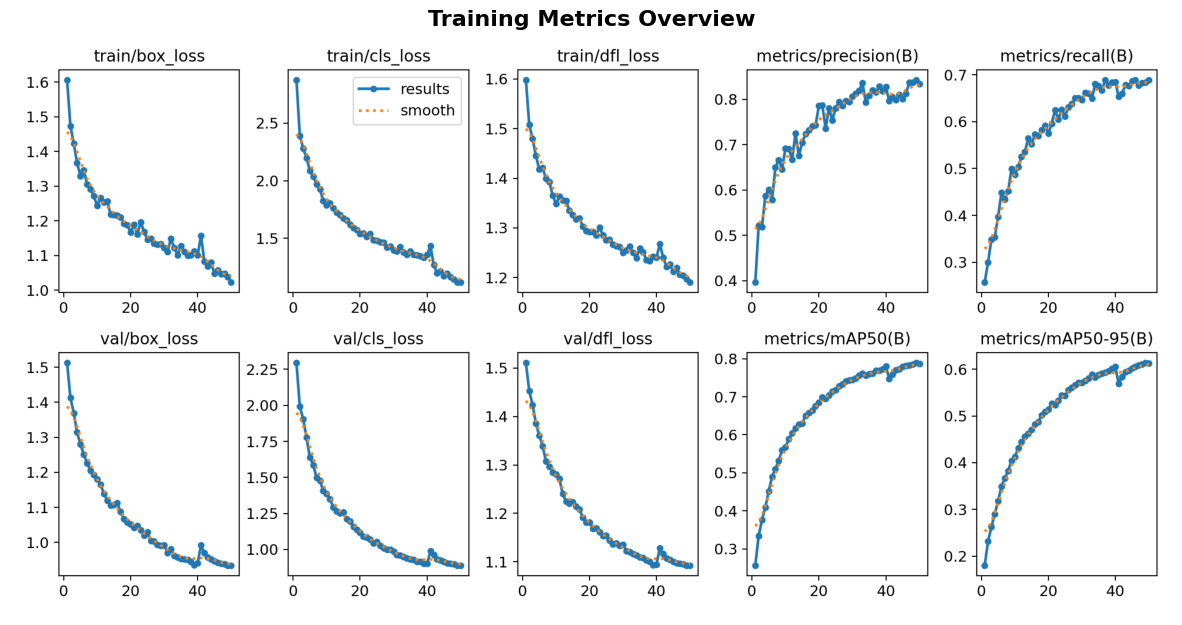


Successfully loaded val_batch0_pred.jpg from /content/runs/detect/val2


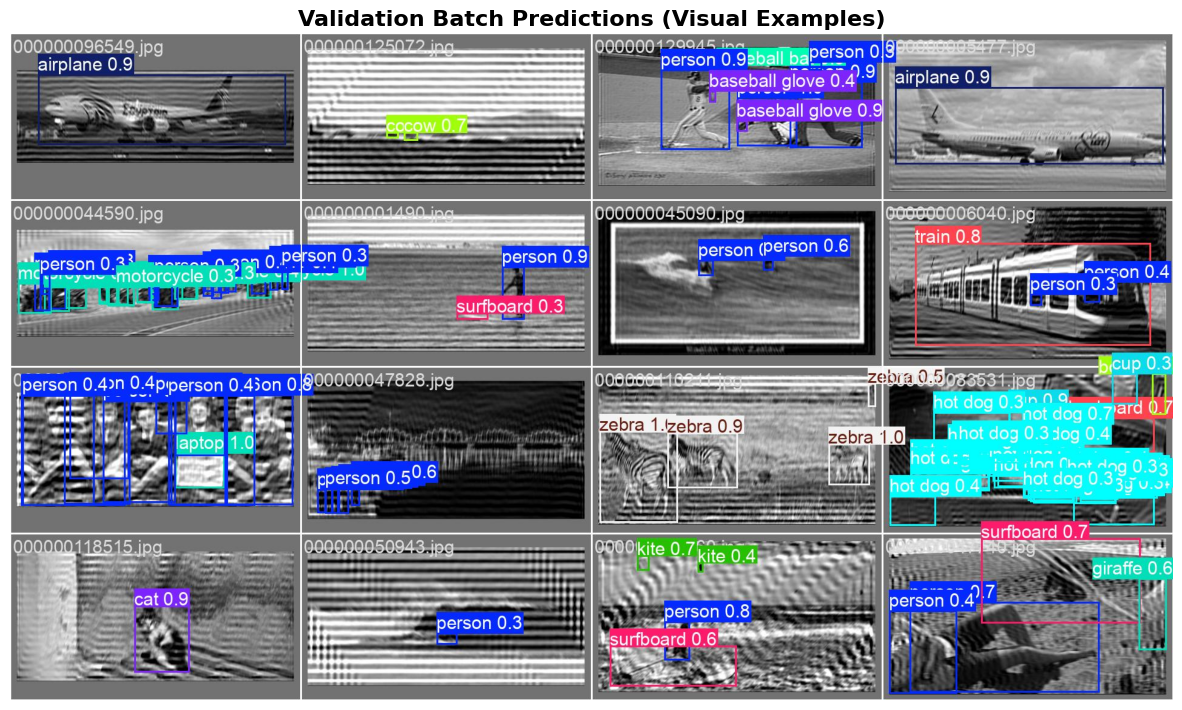

In [21]:
# --- [TASK 5] VISUAL EXAMPLES AND STATISTICAL CURVES ---
import matplotlib.pyplot as plt
import cv2
import os

print("Status: Searching for Task 5 Statistical Curves and Visual Examples...")

# YOLO splits outputs between the training directory and the new validation directory
search_directories = [
    '/content/runs/detect/val2',  # Path from most recent validation run
    '/content/runs/detect/val',   # Fallback validation path
    os.path.join(base_path, 'task4_training_logs', 'deblur_finetune_1200') # Training path
]

# The key visual files needed for the final report
files_to_show = [
    ('Precision-Recall Curve', 'PR_curve.png'),
    ('F1-Confidence Curve', 'F1_curve.png'),
    ('Training Metrics Overview', 'results.png'),
    ('Validation Batch Predictions (Visual Examples)', 'val_batch0_pred.jpg')
]

for title, filename in files_to_show:
    found = False
    for directory in search_directories:
        img_path = os.path.join(directory, filename)
        if os.path.exists(img_path):
            print(f"\nSuccessfully loaded {filename} from {directory}")
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.figure(figsize=(15, 10))
            plt.imshow(img)
            plt.title(title, fontsize=16, fontweight='bold')
            plt.axis('off')
            plt.show()
            found = True
            break # Stop searching once found

    if not found:
        print(f"Warning: Could not find {filename} in any known directories.")